In [1]:
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pymc_ext as pmx
import pytensor.tensor  as pt
import exoplanet as xo

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

# test LogNormal

In [7]:
with pm.Model() as model:
    # rho_2 = pm.Deterministic("rho_2", pt.exp(log_rho))

    # log_prueba1 = pm.Uniform("log_prueba1", lower=np.log(14.0), upper=np.log(18.0))
    # prueba1 = pm.Deterministic("prueba1", pt.exp(log_prueba1))
    # prueba1 = pm.Normal("prueba1", mu=0, sigma=0.2)
    # prueba2 = pm.Normal("prueba2", mu=0, sigma=0.2)
    log_K = pm.Normal("log_K", mu=np.log(2.7), sigma=0.1)
    K = pm.Deterministic("K", pt.exp(log_K))
    # p1 = pm.Deterministic("p1", pt.exp(prueba1))
    # esin = pm.Deterministic("esin", prueba1 * pt.sin(prueba2))
    # ecc = pm.Deterministic("ecc", ecos**2 + esin**2)   # = r^2
    # omega = pm.HalfNormal("omega", sigma=5.0)

In [8]:
# comprobado que lognormal con mu=a, sigma=b es igual a normal con mu=a, sigma=b y luego pt.exp(Normal)
# comprobado que poner sigma=10 en una lognormal es muchísimo, incluso si la media es cero

In [9]:
with model:
    trace = pm.sample(
        tune=2000, #2500,
        draws=2000, #2000,
        chains=2, #4
        return_inferencedata=True,)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [log_K]


Output()

Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


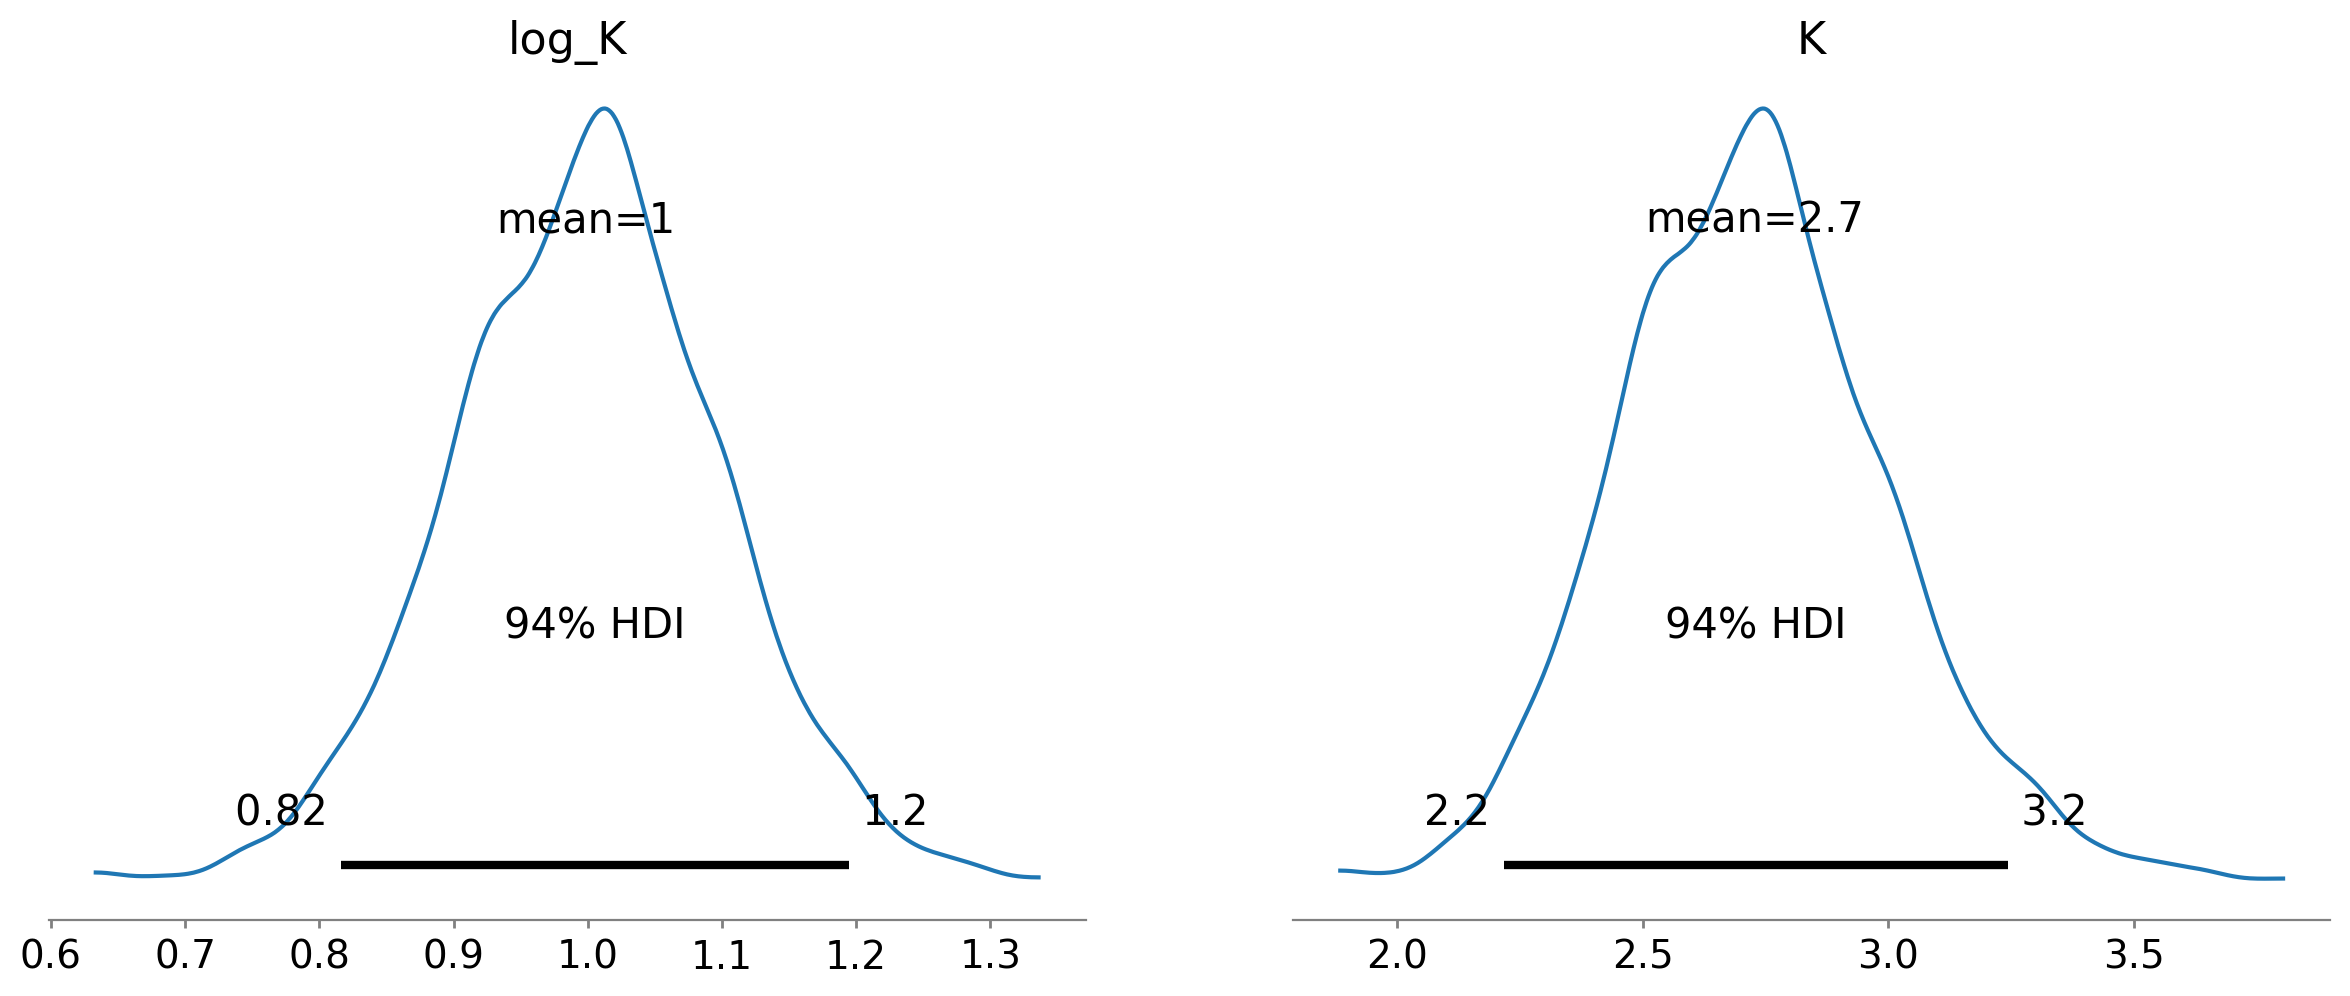

In [10]:
ax = az.plot_posterior(trace)
# plt.xlim(0,200)
# plt.ylim(0, 0.001)

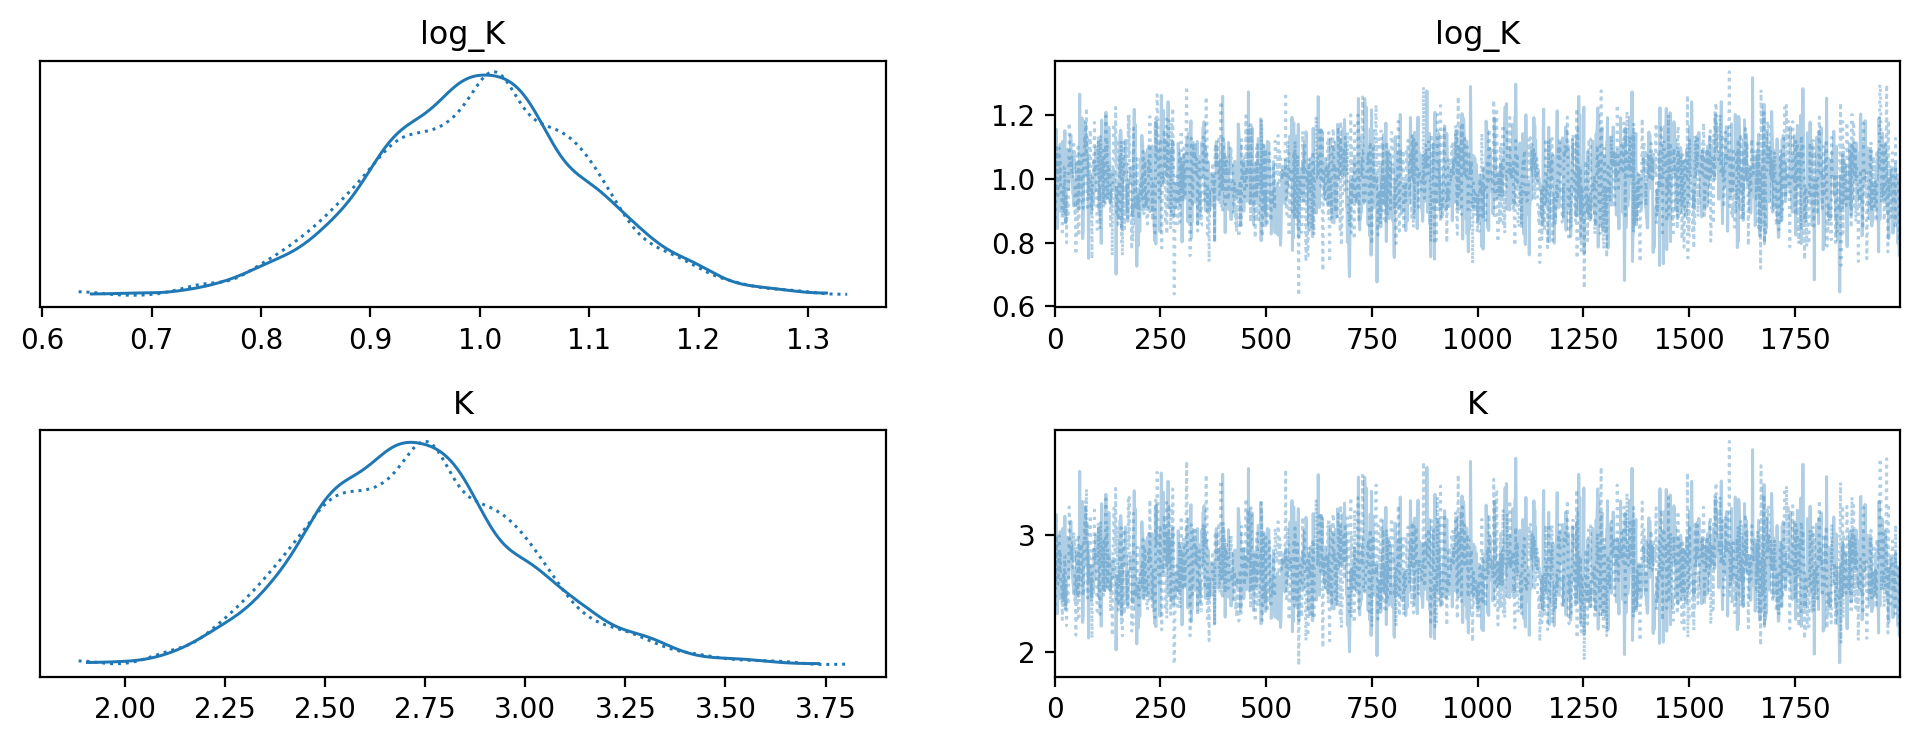

In [11]:
az.plot_trace(trace)
plt.subplots_adjust(hspace=0.5)

In [ ]:
flat_samps = trace.posterior.stack(samples=("chain", "draw"))

In [ ]:
np.median(flat_samps.prueba2.values, axis=0)

In [ ]:
np.exp(np.median(flat_samps.prueba3.values, axis=0))

In [ ]:
plt.hist(flat_samps.prueba4.values, bins=8000);
# plt.xlim(0, 21400)
